In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

In [2]:
TRAIN_DIR = '../dataset/Train'
TEST_DIR = '../dataset/Test'

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

Train path: ../dataset/Train
Test path: ../dataset/Test


In [3]:
train_counts = {}
test_counts = {}

for cls in os.listdir(TRAIN_DIR):
    train_counts[cls] = len(os.listdir(os.path.join(TRAIN_DIR, cls)))

for cls in os.listdir(TEST_DIR):
    test_counts[cls] = len(os.listdir(os.path.join(TEST_DIR, cls)))

print("Training samples per class:")
for k, v in train_counts.items():
    print(f"  {k}: {v}")

print("\nTesting samples per class:")
for k, v in test_counts.items():
    print(f"  {k}: {v}")

Training samples per class:
  glioma: 3018
  meningioma: 2183
  notumor: 1945
  pituitary: 2504

Testing samples per class:
  glioma: 755
  meningioma: 546
  notumor: 487
  pituitary: 626


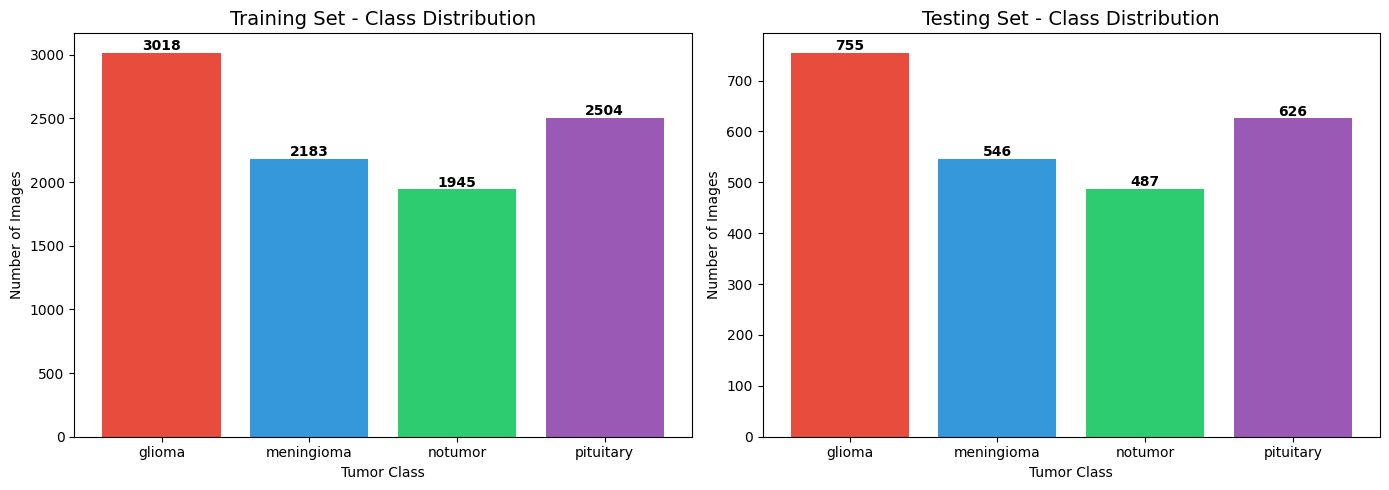

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values(), color=['#e74c3c','#3498db','#2ecc71','#9b59b6'])
axes[0].set_title('Training Set - Class Distribution', fontsize=14)
axes[0].set_xlabel('Tumor Class')
axes[0].set_ylabel('Number of Images')
for i, (k, v) in enumerate(train_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color=['#e74c3c','#3498db','#2ecc71','#9b59b6'])
axes[1].set_title('Testing Set - Class Distribution', fontsize=14)
axes[1].set_xlabel('Tumor Class')
axes[1].set_ylabel('Number of Images')
for i, (k, v) in enumerate(test_counts.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', dpi=150)
plt.show()

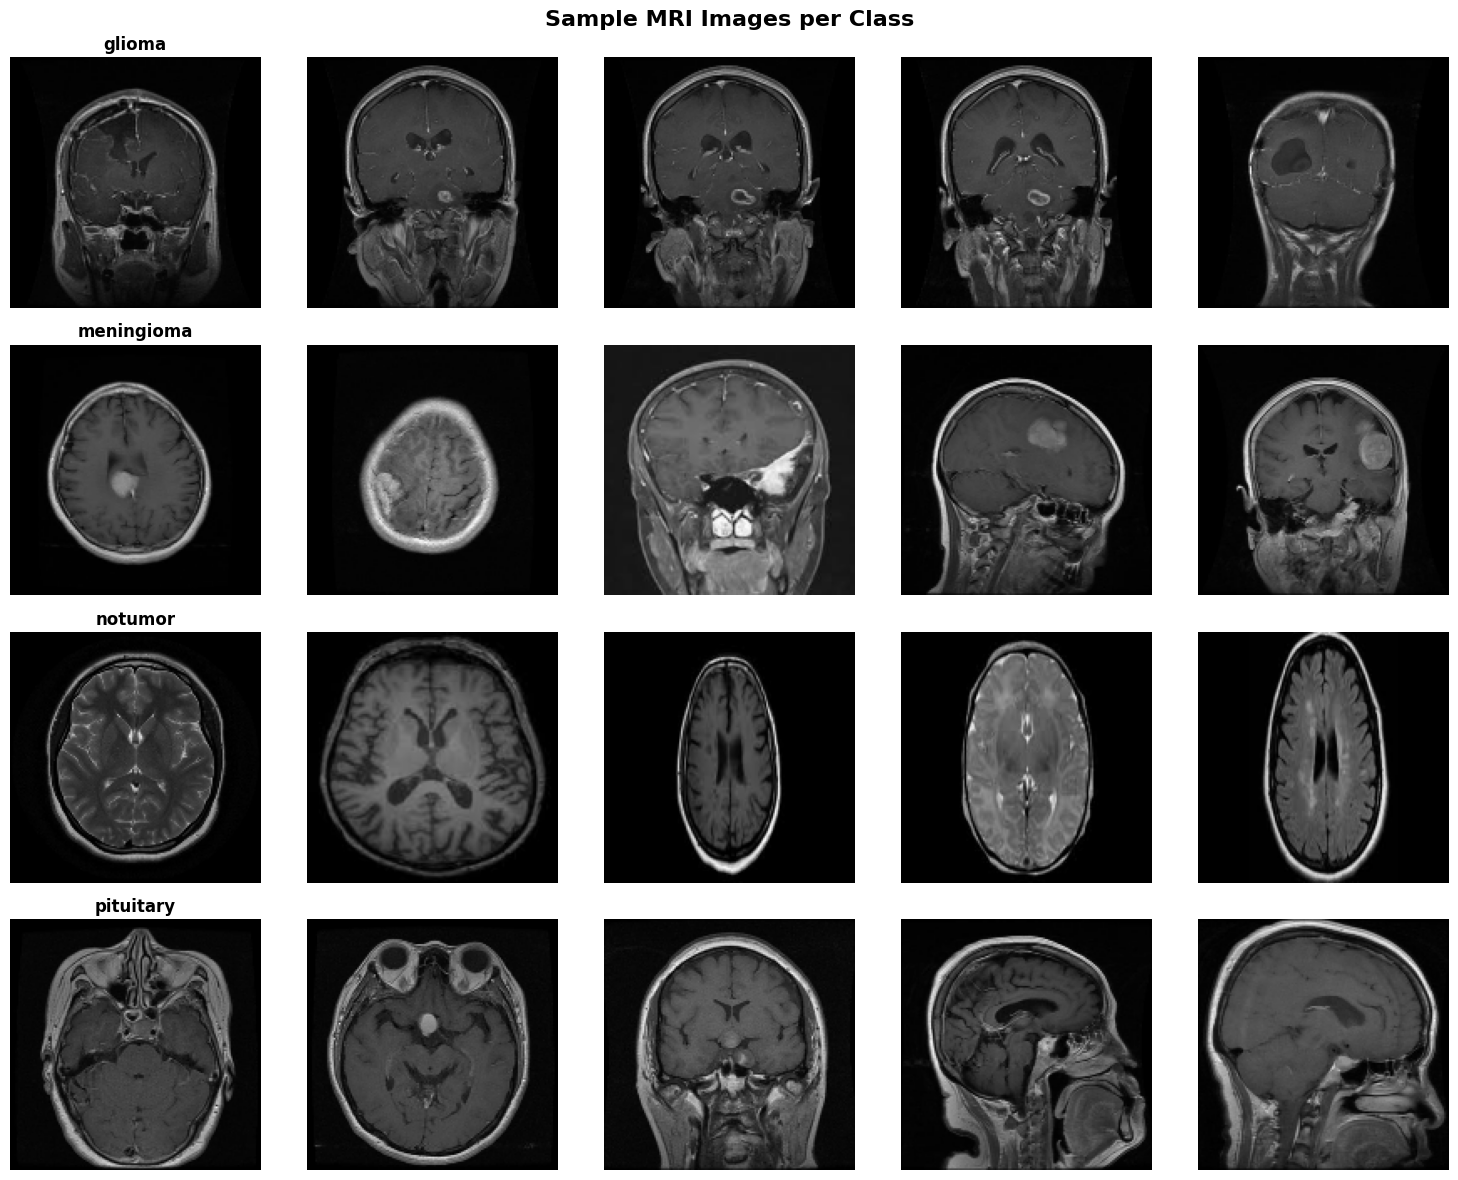

In [6]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:5]
    for col, img_name in enumerate(images):
        img = cv2.imread(os.path.join(cls_path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (150, 150))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/sample_images.png', dpi=150)
plt.show()

Width  — Min: 150, Max: 680, Mean: 434
Height — Min: 168, Max: 680, Mean: 437


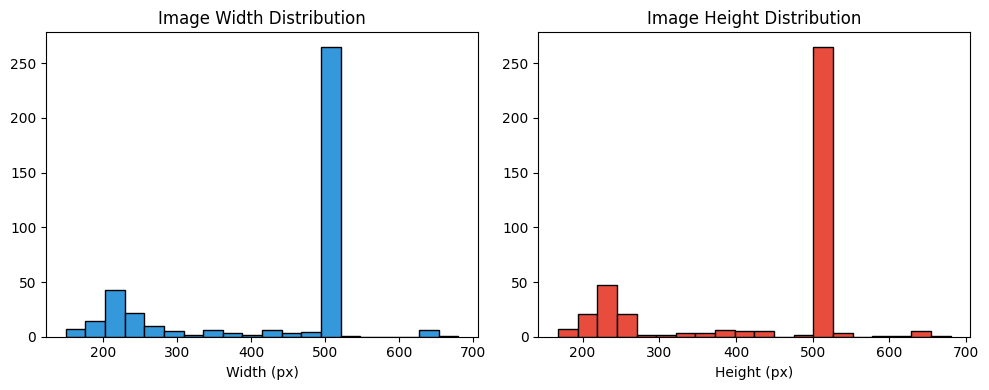

In [7]:
widths, heights = [], []

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path)[:100]:
        img = Image.open(os.path.join(cls_path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  — Min: {min(widths)}, Max: {max(widths)}, Mean: {int(np.mean(widths))}")
print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {int(np.mean(heights))}")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='#3498db', edgecolor='black')
plt.title('Image Width Distribution')
plt.xlabel('Width (px)')

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='#e74c3c', edgecolor='black')
plt.title('Image Height Distribution')
plt.xlabel('Height (px)')

plt.tight_layout()
plt.savefig('../notebooks/image_size_distribution.png', dpi=150)
plt.show()

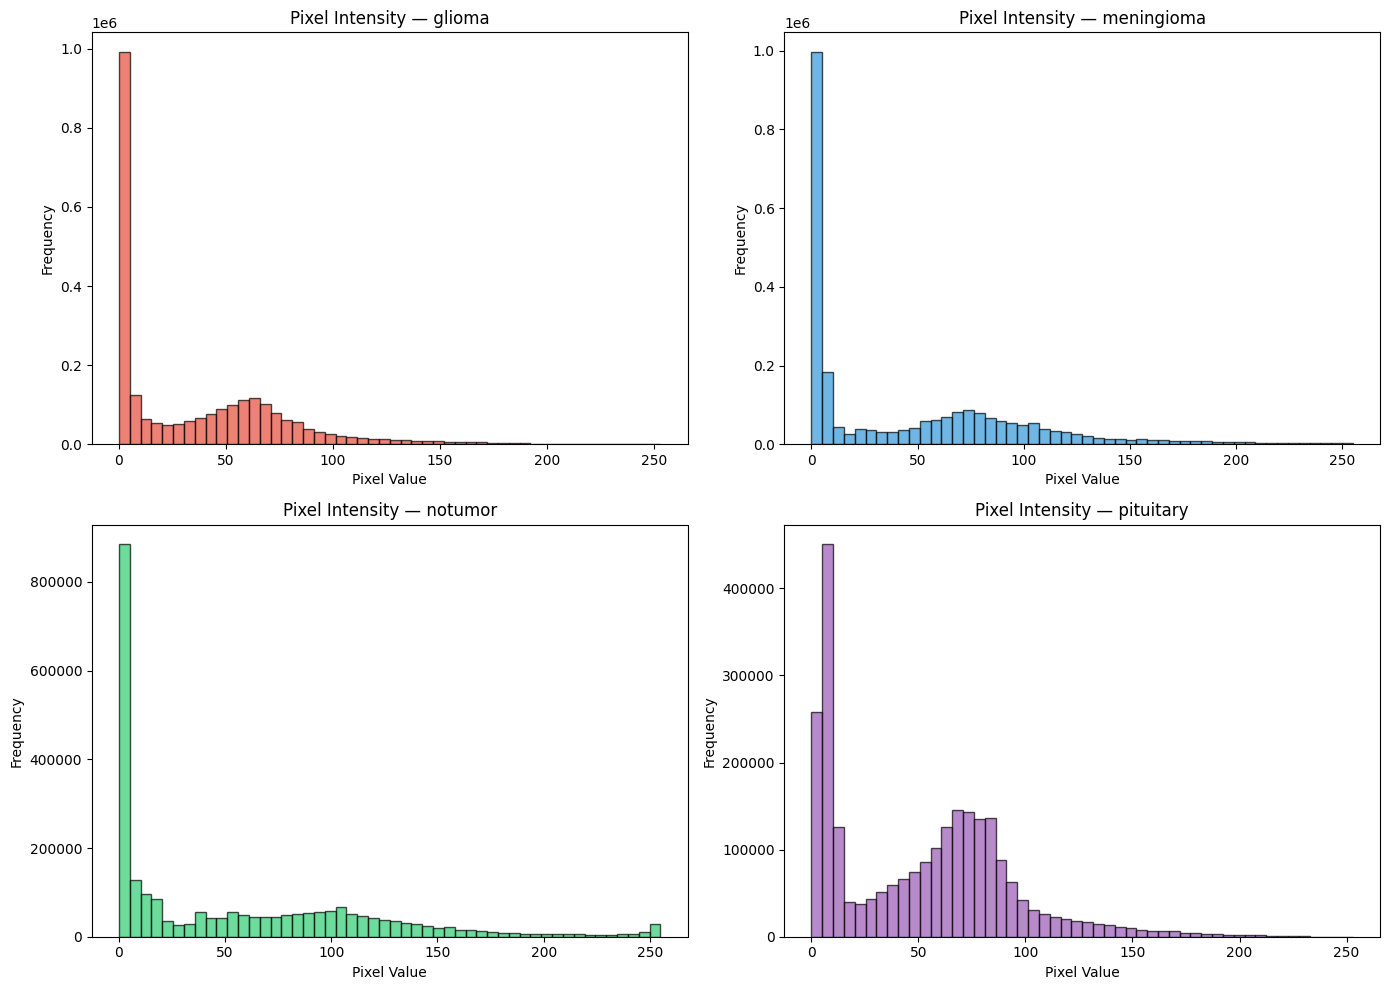

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cls in enumerate(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    pixel_vals = []
    for img_name in os.listdir(cls_path)[:50]:
        img = cv2.imread(os.path.join(cls_path, img_name), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (224, 224))
        pixel_vals.extend(img.flatten())
    axes[idx].hist(pixel_vals, bins=50, color=['#e74c3c','#3498db','#2ecc71','#9b59b6'][idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Pixel Intensity — {cls}', fontsize=12)
    axes[idx].set_xlabel('Pixel Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../notebooks/pixel_intensity.png', dpi=150)
plt.show()

In [9]:
total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
total = total_train + total_test

print("=" * 40)
print("         DATASET SUMMARY")
print("=" * 40)
print(f"Total Images     : {total}")
print(f"Training Images  : {total_train}")
print(f"Testing Images   : {total_test}")
print(f"Number of Classes: {len(train_counts)}")
print(f"Classes          : {list(train_counts.keys())}")
print("=" * 40)
print("\nClass Imbalance Check:")
for k, v in train_counts.items():
    pct = (v / total_train) * 100
    print(f"  {k}: {v} ({pct:.1f}%)")
print("\nEDA Complete!")

         DATASET SUMMARY
Total Images     : 12064
Training Images  : 9650
Testing Images   : 2414
Number of Classes: 4
Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']

Class Imbalance Check:
  glioma: 3018 (31.3%)
  meningioma: 2183 (22.6%)
  notumor: 1945 (20.2%)
  pituitary: 2504 (25.9%)

EDA Complete!
